# 05 - Strong Ablation Official Mini

Runs the Strong Official-Mini ablation suite on the current multi-batch pipeline.

This notebook keeps the real H16 scope: 4 prepared-data batches, 4 frozen-VLM encoded-feature batches, full train split, full test split, action mask, and denormalized raw action metrics. H8 ablation is attempted only if real H8 prepared/encoded inputs are attached; otherwise it is explicitly marked skipped.

In [1]:
# Offline-safe cell. Do not pip install here; RTX6000/Nemotron sessions can run without internet.

In [2]:
from pathlib import Path
import json, math, time, random, os
import numpy as np, pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Beta

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available(): print("gpu:", torch.cuda.get_device_name(0))

SMOKE_TEST = False
STATE_HORIZON = 1
BATCH_SIZE = int(os.getenv("ABLATION_BATCH_SIZE", "256"))
EVAL_BATCH_SIZE = int(os.getenv("ABLATION_EVAL_BATCH_SIZE", "512"))
EPOCHS = 1
NUM_WORKERS = int(os.getenv("ABLATION_NUM_WORKERS", "2"))
USE_AMP = True
MAX_TRAIN_SAMPLES = 2048 if SMOKE_TEST else None
MAX_EVAL_SAMPLES = 1024 if SMOKE_TEST else None
MAX_STEPS_PER_EPOCH = 20 if SMOKE_TEST else None
EXPECTED_H16_PREPARED_BATCHES = int(os.getenv("EXPECTED_H16_PREPARED_BATCHES", "4"))
EXPECTED_H16_ENCODED_BATCHES = int(os.getenv("EXPECTED_H16_ENCODED_BATCHES", "4"))
OUTPUT_ROOT = Path("/kaggle/working/gr00t_official_ablation")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RUNS = [
    {"run":"state_vl_layers8_lr1e4", "type":"component/model/hyperparam", "use_vl":True, "layers":8, "hidden":512, "lr":1e-4, "H":16},
    {"run":"state_only_layers8_lr1e4", "type":"component", "use_vl":False, "layers":8, "hidden":512, "lr":1e-4, "H":16},
    {"run":"state_vl_layers4_lr1e4", "type":"model", "use_vl":True, "layers":4, "hidden":512, "lr":1e-4, "H":16},
    {"run":"state_vl_layers8_lr5e5", "type":"hyperparam", "use_vl":True, "layers":8, "hidden":512, "lr":5e-5, "H":16},
    {"run":"state_vl_H8_lr1e4", "type":"horizon", "use_vl":True, "layers":8, "hidden":512, "lr":1e-4, "H":8},
]
K_VALUES = [1, 4, 8, 16]
print(json.dumps({"batch_size": BATCH_SIZE, "eval_batch_size": EVAL_BATCH_SIZE, "max_train_samples": MAX_TRAIN_SAMPLES, "max_eval_samples": MAX_EVAL_SAMPLES, "max_steps_per_epoch": MAX_STEPS_PER_EPOCH, "runs": [r["run"] for r in RUNS], "K_VALUES": K_VALUES}, indent=2))


device: cuda
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
{
  "batch_size": 256,
  "eval_batch_size": 512,
  "max_train_samples": null,
  "max_eval_samples": null,
  "max_steps_per_epoch": null,
  "runs": [
    "state_vl_layers8_lr1e4",
    "state_only_layers8_lr1e4",
    "state_vl_layers4_lr1e4",
    "state_vl_layers8_lr5e5",
    "state_vl_H8_lr1e4"
  ],
  "K_VALUES": [
    1,
    4,
    8,
    16
  ]
}


In [3]:
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim, buckets=1000):
        super().__init__()
        self.buckets = buckets
        self.embed = nn.Embedding(buckets, hidden_dim)
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
    def forward(self, t):
        idx = torch.clamp((t * self.buckets).long(), 0, self.buckets - 1)
        return self.mlp(self.embed(idx))

class CrossBlock(nn.Module):
    def __init__(self, hidden_dim, heads, dropout):
        super().__init__()
        self.n1 = nn.LayerNorm(hidden_dim)
        self.sa = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.n2 = nn.LayerNorm(hidden_dim)
        self.ca = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.n3 = nn.LayerNorm(hidden_dim)
        self.ff = nn.Sequential(nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim * 4, hidden_dim), nn.Dropout(dropout))
    def forward(self, x, mem):
        y = self.n1(x)
        x = x + self.sa(y, y, y, need_weights=False)[0]
        y = self.n2(x)
        x = x + self.ca(y, mem, mem, need_weights=False)[0]
        return x + self.ff(self.n3(x))

class OfficialMiniVLDiT(nn.Module):
    def __init__(self, state_dim, action_dim, state_horizon, action_horizon, vl_dim, hidden_dim=512, layers=8, heads=8, dropout=0.1, buckets=1000):
        super().__init__()
        self.state_horizon = state_horizon
        self.action_horizon = action_horizon
        self.state_proj = nn.Linear(state_dim, hidden_dim)
        self.action_proj = nn.Linear(action_dim, hidden_dim)
        self.vl_proj = nn.Linear(vl_dim, hidden_dim)
        self.time = TimeEmbedding(hidden_dim, buckets)
        self.state_pos = nn.Embedding(state_horizon, hidden_dim)
        self.action_pos = nn.Embedding(action_horizon, hidden_dim)
        self.blocks = nn.ModuleList([CrossBlock(hidden_dim, heads, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(hidden_dim)
        self.out = nn.Linear(hidden_dim, action_dim)
    def forward(self, noisy_action, state_history, vl_features, t):
        s_pos = self.state_pos(torch.arange(self.state_horizon, device=noisy_action.device))[None]
        a_pos = self.action_pos(torch.arange(self.action_horizon, device=noisy_action.device))[None]
        s = self.state_proj(state_history) + s_pos
        a = self.action_proj(noisy_action) + a_pos
        x = torch.cat([s, a], dim=1) + self.time(t)[:, None, :]
        mem = self.vl_proj(vl_features)
        for block in self.blocks:
            x = block(x, mem)
        return self.out(self.norm(x[:, self.state_horizon:]))


In [4]:
REQUIRED_PREPARED_FILES = ["states_train.npy", "actions_train_chunk.npy", "action_mask_train.npy", "states_test.npy", "actions_test_chunk.npy", "action_mask_test.npy", "normalization_stats.json"]
REQUIRED_ENCODED_FILES = ["vl_features_train.npy", "vl_feature_index_train.parquet", "vl_features_test.npy", "vl_feature_index_test.parquet", "encode_summary.json"]
REQUIRED_RUN_FILES = ["checkpoint_last.pt", "config.json", "train_summary.json"]

def _has_required(root, required):
    return root.is_dir() and all((root / name).exists() for name in required)

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def find_prepared_roots(H):
    exact = f"gr00t_prepared_official_H{H}"
    prefix = f"gr00t_prepared_official_H{H}_batch"
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists(): continue
        for c in base.rglob(f"gr00t_prepared_official_H{H}*"):
            if (c.name == exact or c.name.startswith(prefix)) and _has_required(c, REQUIRED_PREPARED_FILES):
                candidates.append(c)
    roots = sorted({str(c.resolve()): c for c in candidates}.values(), key=lambda x: str(x))
    batch_roots = [r for r in roots if r.name.startswith(prefix)]
    if batch_roots: roots = batch_roots
    if H == 16 and len(roots) < EXPECTED_H16_PREPARED_BATCHES:
        raise RuntimeError(f"Expected {EXPECTED_H16_PREPARED_BATCHES} H16 prepared roots, found {len(roots)}")
    return roots

def find_encoded_roots(H):
    patterns = [f"gr00t_vlm_encoded_H{H}_batch*_full_rtx6000_offline", f"gr00t_vlm_encoded_H{H}_batch*_rtx6000_offline", f"gr00t_vlm_encoded_H{H}_20subsets*"]
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists(): continue
        for pattern in patterns:
            for c in base.rglob(pattern):
                if _has_required(c, REQUIRED_ENCODED_FILES): candidates.append(c)
    roots = sorted({str(c.resolve()): c for c in candidates}.values(), key=lambda x: str(x))
    if H == 16 and len(roots) < EXPECTED_H16_ENCODED_BATCHES:
        raise RuntimeError(f"Expected {EXPECTED_H16_ENCODED_BATCHES} H16 encoded roots, found {len(roots)}")
    return roots

def find_run_root(H):
    candidates=[]
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists(): continue
        for c in base.rglob(f"official_mini_vldit_H{H}*"):
            if _has_required(c, REQUIRED_RUN_FILES): candidates.append(c)
    roots=sorted({str(c.resolve()): c for c in candidates}.values(), key=lambda x: str(x))
    return roots[0] if roots else None

def combine_normalization_stats(stats_list):
    def combine(mean_key, std_key, n_key):
        total_n = int(sum(int(s.get(n_key, 0)) for s in stats_list))
        if total_n <= 0:
            means = np.stack([np.asarray(s[mean_key], dtype=np.float64) for s in stats_list])
            stds = np.stack([np.asarray(s[std_key], dtype=np.float64) for s in stats_list])
            mean = means.mean(axis=0); std = np.maximum(stds.mean(axis=0), 1e-6)
            return mean.astype(np.float32).tolist(), std.astype(np.float32).tolist(), int(len(stats_list))
        sx = None; sx2 = None
        for s in stats_list:
            n = int(s.get(n_key, 0))
            if n <= 0: continue
            mean = np.asarray(s[mean_key], dtype=np.float64)
            std = np.asarray(s[std_key], dtype=np.float64)
            part_x = mean * n
            part_x2 = (std ** 2 + mean ** 2) * n
            sx = part_x if sx is None else sx + part_x
            sx2 = part_x2 if sx2 is None else sx2 + part_x2
        mean = sx / total_n
        var = np.maximum(sx2 / total_n - mean ** 2, 1e-12)
        std = np.where(np.sqrt(var) < 1e-6, 1.0, np.sqrt(var))
        return mean.astype(np.float32).tolist(), std.astype(np.float32).tolist(), total_n
    sm, ss, sn = combine("state_mean", "state_std", "state_n")
    am, ast, an = combine("action_mean", "action_std", "action_n")
    return {"state_mean": sm, "state_std": ss, "action_mean": am, "action_std": ast, "state_n": sn, "action_n": an}

def _summary_count(summary, split, key):
    return int((summary.get(split) or {}).get(key) or 0)

def _prepared_names_from_encode_summary(summary):
    return [Path(str(raw)).name for raw in (summary.get("prepared_roots") or []) if Path(str(raw)).name]

def _build_real_context(H):
    prepared_roots = find_prepared_roots(H)
    encoded_roots = find_encoded_roots(H)
    run_root = find_run_root(H)
    if not prepared_roots:
        return {"H": H, "available": False, "reason": f"missing prepared H{H}", "source": "missing"}
    if not encoded_roots:
        return {"H": H, "available": False, "reason": f"missing encoded VLM features H{H}", "source": "missing"}
    prepared_by_id = {i: r for i, r in enumerate(prepared_roots)}
    prepared_name_to_id = {r.name: i for i, r in prepared_by_id.items()}
    encoded_infos=[]
    for enc_id, root in enumerate(encoded_roots):
        summary=load_json(root/"encode_summary.json")
        prepared_names=_prepared_names_from_encode_summary(summary)
        unknown=[n for n in prepared_names if n not in prepared_name_to_id]
        if unknown: raise RuntimeError(f"Encoded root {root} refers to unattached prepared roots: {unknown}")
        if not prepared_names and len(prepared_roots)==1: prepared_names=[prepared_roots[0].name]
        if not prepared_names: raise RuntimeError(f"Encoded root {root} does not report prepared_roots")
        encoded_infos.append({"encoded_root_id": enc_id, "root": root, "summary": summary, "prepared_names": prepared_names, "prepared_global_ids": [prepared_name_to_id[n] for n in prepared_names]})
    stats=combine_normalization_stats([load_json(r/"normalization_stats.json") for r in prepared_roots])
    return {"H": H, "storage_H": H, "available": True, "source": "real_prepared_H", "prepared_roots": prepared_roots, "prepared_by_id": prepared_by_id, "encoded_infos": encoded_infos, "run_root": run_root, "stats": stats,
            "train_encoded": sum(_summary_count(info["summary"], "train", "encoded") for info in encoded_infos),
            "test_encoded": sum(_summary_count(info["summary"], "test", "encoded") for info in encoded_infos)}

def build_context(H):
    ctx = _build_real_context(H)
    if ctx.get("available") or H != 8:
        return ctx
    # Complete H ablation even when a separately re-prepared H8 dataset has not been attached.
    # This is a faithful action-horizon ablation on the same full H16 sample/frame set: H8 uses the first 8 action/mask steps.
    base = _build_real_context(16)
    if not base.get("available"):
        return {"H": H, "available": False, "reason": "missing H8 and H16 fallback context", "source": "missing"}
    derived = dict(base)
    derived.update({"H": 8, "storage_H": 16, "available": True, "source": "derived_from_H16_prefix", "derived_from_H": 16,
                    "reason": "real H8 prepared data not attached; using first 8 steps from full H16 action chunks"})
    return derived

CONTEXTS = {H: build_context(H) for H in [16, 8]}
print(json.dumps({H: {k: (str(v) if isinstance(v, Path) else v) for k,v in ctx.items() if k in ["H","storage_H","available","reason","source","derived_from_H","train_encoded","test_encoded"]} for H,ctx in CONTEXTS.items()}, indent=2))
if CONTEXTS[16]["available"]:
    print("H16 prepared roots:", [str(r) for r in CONTEXTS[16]["prepared_roots"]])
    print("H16 encoded roots:", [str(info["root"]) for info in CONTEXTS[16]["encoded_infos"]])
    print("H16 run root:", CONTEXTS[16]["run_root"])


{
  "16": {
    "H": 16,
    "storage_H": 16,
    "available": true,
    "source": "real_prepared_H",
    "train_encoded": 3022069,
    "test_encoded": 755702
  },
  "8": {
    "H": 8,
    "storage_H": 16,
    "available": true,
    "source": "derived_from_H16_prefix",
    "train_encoded": 3022069,
    "test_encoded": 755702,
    "derived_from_H": 16,
    "reason": "real H8 prepared data not attached; using first 8 steps from full H16 action chunks"
  }
}
H16 prepared roots: ['/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch01-5-subsets/gr00t_prepared_official_H16_batch01', '/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch02-5-subsets/gr00t_prepared_official_H16_batch02', '/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch03-5-subsets/gr00t_prepared_official_H16_batch03', '/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch04-5-subsets/gr00t_prepared_official_H16_batch04']
H16 encoded roots: ['/kaggle/input/notebooks/kimthanh211005/gr0

In [5]:
class MultiBatchDS(Dataset):
    def __init__(self, ctx, split, use_vl=True, max_samples=None):
        self.ctx = ctx; self.split = split; self.use_vl = use_vl; self.H = int(ctx["H"])
        self.roots = ctx["prepared_by_id"]
        self.states = {rid: np.load(root / f"states_{split}.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.actions = {rid: np.load(root / f"actions_{split}_chunk.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.masks = {rid: np.load(root / f"action_mask_{split}.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.features = {}
        index_parts=[]
        for info in ctx["encoded_infos"]:
            enc_id=int(info["encoded_root_id"]); root=info["root"]
            self.features[enc_id]=np.load(root/f"vl_features_{split}.npy", mmap_mode="r")
            idx=pd.read_parquet(root/f"vl_feature_index_{split}.parquet").sort_values("feature_index").reset_index(drop=True)
            if "root_id" not in idx.columns: raise ValueError(f"Feature index is missing root_id: {root}")
            local_ids=sorted(int(x) for x in idx.root_id.dropna().unique().tolist())
            global_ids=[int(x) for x in info["prepared_global_ids"]]
            if len(global_ids)==1:
                local_to_global={local_id: global_ids[0] for local_id in local_ids}
            elif len(local_ids)==len(global_ids):
                local_to_global={local_id: global_id for local_id, global_id in zip(local_ids, global_ids)}
            else:
                raise RuntimeError(f"Cannot remap local ids {local_ids} from {root}")
            idx["encoded_root_id"]=enc_id
            idx["local_root_id"]=idx["root_id"].astype(int)
            idx["root_id"]=idx["local_root_id"].map(local_to_global).astype(int)
            index_parts.append(idx)
        self.index=pd.concat(index_parts, ignore_index=True)
        sort_cols=[c for c in ["root_id","subset","episode_index","frame_index","sample_id","encoded_root_id","feature_index"] if c in self.index.columns]
        self.index=self.index.sort_values(sort_cols).reset_index(drop=True)
        if max_samples is not None and len(self.index)>max_samples:
            self.index=self.index.sample(n=int(max_samples), random_state=SEED).reset_index(drop=True)
        self.encoded_root_ids=self.index["encoded_root_id"].to_numpy(np.int64)
        self.root_ids=self.index["root_id"].to_numpy(np.int64)
        self.sample_ids=self.index["sample_id"].to_numpy(np.int64)
        self.feature_indices=self.index["feature_index"].to_numpy(np.int64)
        self.subsets=self.index["subset"].astype(str).to_numpy()
        stats=ctx["stats"]
        self.sm=np.asarray(stats["state_mean"],np.float32); self.ss=np.asarray(stats["state_std"],np.float32)
        self.am=np.asarray(stats["action_mean"],np.float32); self.asd=np.asarray(stats["action_std"],np.float32)
        feature_shapes={enc_id: tuple(arr.shape[1:]) for enc_id,arr in self.features.items()}
        if len(set(feature_shapes.values()))!=1: raise RuntimeError(f"Inconsistent feature shapes: {feature_shapes}")
        self.feature_shape=next(iter(feature_shapes.values()))
        self.vl_dim=int(self.feature_shape[-1]) if use_vl else 1
        self.vl_tokens=int(self.feature_shape[0]) if use_vl else 1
    def __len__(self): return len(self.sample_ids)
    def __getitem__(self, i):
        enc_id=int(self.encoded_root_ids[i]); rid=int(self.root_ids[i]); sid=int(self.sample_ids[i]); fid=int(self.feature_indices[i])
        raw_state=np.asarray(self.states[rid][sid],np.float32)
        raw_action=np.asarray(self.actions[rid][sid],np.float32)
        mask=np.asarray(self.masks[rid][sid],np.float32).copy()
        if raw_action.shape[0] < self.H or mask.shape[0] < self.H:
            raise RuntimeError(f"Stored action/mask horizon is shorter than requested H={self.H}: action={raw_action.shape}, mask={mask.shape}")
        raw_action=raw_action[:self.H]
        mask=mask[:self.H]
        action_finite=np.isfinite(raw_action)
        raw_state=np.where(np.isfinite(raw_state),raw_state,0.0).astype(np.float32,copy=False)
        raw_action=np.where(action_finite,raw_action,0.0).astype(np.float32,copy=False)
        mask=np.where(np.isfinite(mask),mask,0.0).astype(np.float32,copy=False)
        mask=np.clip(mask*action_finite.astype(np.float32),0.0,1.0).astype(np.float32,copy=False)
        state=np.nan_to_num((raw_state-self.sm)/self.ss,nan=0.0,posinf=0.0,neginf=0.0).astype(np.float32,copy=False)
        action=np.nan_to_num((raw_action-self.am)/self.asd,nan=0.0,posinf=0.0,neginf=0.0).astype(np.float32,copy=False)*mask
        if self.use_vl:
            vl=np.nan_to_num(np.asarray(self.features[enc_id][fid],np.float32),nan=0.0,posinf=0.0,neginf=0.0).astype(np.float32,copy=False)
        else:
            vl=np.zeros((1,1),np.float32)
        return {"state":torch.from_numpy(state),"action":torch.from_numpy(action),"mask":torch.from_numpy(mask),"vl":torch.from_numpy(vl),"subset":str(self.subsets[i])}

def collate(batch):
    out={k: torch.stack([b[k] for b in batch]) for k in ["state","action","mask","vl"]}
    out["subset"]=[b["subset"] for b in batch]
    return out

def make_loader(ds, train):
    return DataLoader(ds,batch_size=BATCH_SIZE if train else EVAL_BATCH_SIZE,shuffle=train,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available(),drop_last=train,collate_fn=collate)

def _to_device(b):
    state=torch.nan_to_num(b["state"].to(device,non_blocking=True),nan=0.0,posinf=0.0,neginf=0.0)
    action=torch.nan_to_num(b["action"].to(device,non_blocking=True),nan=0.0,posinf=0.0,neginf=0.0)
    mask=torch.nan_to_num(b["mask"].to(device,non_blocking=True),nan=0.0,posinf=0.0,neginf=0.0).clamp_(0.0,1.0)
    vl=torch.nan_to_num(b["vl"].to(device,non_blocking=True),nan=0.0,posinf=0.0,neginf=0.0)
    return state, action*mask, mask, vl


In [6]:
def train_eval(run):
    H=run["H"]; ctx=CONTEXTS.get(H)
    if not ctx or not ctx.get("available"):
        return {"run":run["run"],"status":"skipped","type":run["type"],"reason":ctx.get("reason") if ctx else f"missing context H{H}","H":H}
    try:
        tr=MultiBatchDS(ctx,"train",run["use_vl"],MAX_TRAIN_SAMPLES)
        ev=MultiBatchDS(ctx,"test",run["use_vl"],MAX_EVAL_SAMPLES)
    except Exception as exc:
        return {"run":run["run"],"status":"skipped","type":run["type"],"reason":repr(exc),"H":H}
    tl=make_loader(tr, train=True); el=make_loader(ev, train=False)
    model=OfficialMiniVLDiT(44,44,STATE_HORIZON,H,tr.vl_dim,run["hidden"],run["layers"],8,.1).to(device)
    num_params=sum(p.numel() for p in model.parameters())
    opt=torch.optim.AdamW(model.parameters(),lr=run["lr"],weight_decay=1e-5,betas=(.95,.999),eps=1e-8)
    scaler=torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())
    beta=Beta(torch.tensor(1.5,device=device),torch.tensor(1.0,device=device))
    losses=[]; train_start=time.time(); steps=0; model.train(); max_steps=len(tl) if MAX_STEPS_PER_EPOCH is None else min(MAX_STEPS_PER_EPOCH,len(tl))
    for i,b in enumerate(tqdm(tl,total=max_steps,desc=f"train {run['run']}")):
        if i>=max_steps: break
        state,action,mask,vl=_to_device(b)
        t=beta.sample((action.size(0),)).to(device=device,dtype=action.dtype).clamp_(1e-4,1.0-1e-4)
        noise=torch.randn_like(action)*mask
        noisy=((1-t[:,None,None])*noise+t[:,None,None]*action)*mask
        target=(action-noise)*mask
        valid=mask>0
        if valid.sum().item()<=0: continue
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):
            pred=torch.nan_to_num(model(noisy,state,vl,t),nan=0.0,posinf=0.0,neginf=0.0)*mask
            sqerr=torch.where(valid,(pred-target).pow(2),torch.zeros_like(target))
            loss=sqerr.sum()/valid.sum().clamp_min(1)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite loss in {run['run']} step={steps+1}")
        scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); scaler.step(opt); scaler.update()
        losses.append(float(loss.detach().cpu())); steps+=1
    model.eval()
    am=torch.tensor(ev.am,device=device)[None,None,:]; ast=torch.tensor(ev.asd,device=device)[None,None,:]
    @torch.no_grad()
    def sample(state,vl,K):
        x=torch.zeros(state.size(0),H,44,device=state.device,dtype=state.dtype); dt=1.0/K
        for k in range(K):
            tt=torch.full((state.size(0),),k/K,device=state.device,dtype=state.dtype)
            x=torch.nan_to_num(x+dt*model(x,state,vl,tt),nan=0.0,posinf=0.0,neginf=0.0)
        return x
    k_rows=[]
    with torch.no_grad():
        for K in K_VALUES:
            sq=ab=count=samples=0; eval_start=time.time()
            for b in tqdm(el,desc=f"eval {run['run']} K={K}"):
                state,action,mask,vl=_to_device(b)
                pred=sample(state,vl,K)*mask
                diff=(pred.float()*ast+am)-(action.float()*ast+am)
                sq+=float((diff.square()*mask).sum().cpu()); ab+=float((diff.abs()*mask).sum().cpu()); count+=int(mask.sum().cpu()); samples+=int(action.size(0))
            mse=sq/max(count,1); k_rows.append({"K":K,"raw_mse":mse,"raw_mae":ab/max(count,1),"raw_rmse":math.sqrt(mse),"eval_samples":samples,"eval_elapsed_sec":round(time.time()-eval_start,2)})
    best=next(x for x in k_rows if x["K"]==4)
    del model, opt, scaler
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {"run":run["run"],"status":"completed","type":run["type"],"use_vl":run["use_vl"],"H":H,"layers":run["layers"],"hidden_dim":run["hidden"],"lr":run["lr"],"num_params":int(num_params),"train_samples":int(len(tr)),"eval_samples":int(len(ev)),"full_train_epoch_completed":MAX_TRAIN_SAMPLES is None and MAX_STEPS_PER_EPOCH is None,"full_eval_completed":MAX_EVAL_SAMPLES is None,"global_steps":steps,"train_last_loss":losses[-1] if losses else None,"train_elapsed_sec":round(time.time()-train_start,2),**best,"k_results":k_rows}

results=[]
for run in RUNS:
    res=train_eval(run)
    print(json.dumps({k:v for k,v in res.items() if k!='k_results'}, indent=2))
    results.append(res)


/tmp/ipykernel_65/144600083.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())


train state_vl_layers8_lr1e4:   0%|          | 0/11804 [00:00<?, ?it/s]

/tmp/ipykernel_65/144600083.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):


eval state_vl_layers8_lr1e4 K=1:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>^
^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ 

...

eval state_vl_H8_lr1e4 K=8:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180><function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():

             ^ ^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

eval state_vl_H8_lr1e4 K=16:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

{
  "run": "state_vl_H8_lr1e4",
  "status": "completed",
  "type": "horizon",
  "use_vl": true,
  "H": 8,
  "layers": 8,
  "hidden_dim": 512,
  "lr": 0.0001,
  "num_params": 35268140,
  "train_samples": 3022069,
  "eval_samples": 755702,
  "full_train_epoch_completed": true,
  "full_eval_completed": true,
  "global_steps": 11804,
  "train_last_loss": 0.1141531690955162,
  "train_elapsed_sec": 562.5,
  "K": 4,
  "raw_mse": 0.32561595412925926,
  "raw_mae": 0.1223268781962739,
  "raw_rmse": 0.5706276843347676,
  "eval_elapsed_sec": 53.94
}


eval pretrain_only:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

eval posttrain_task_specific:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7836bd210180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

,run,status,type,use_vl,H,layers,hidden_dim,lr,num_params,train_samples,...,full_eval_completed,global_steps,train_last_loss,train_elapsed_sec,K,raw_mse,raw_mae,raw_rmse,eval_elapsed_sec,checkpoint
0,state_vl_layers8_lr1e4,completed,component/model/hyperparam,True,16,8,512,0.00010,35272236.0,3022069.0,...,True,11804,0.091674,990.04,4,0.580838,0.205588,0.762127,81.95,NaN
1,state_only_layers8_lr1e4,completed,component,False,16,8,512,0.00010,34486316.0,3022069.0,...,True,11804,0.161847,766.54,4,0.685172,0.236109,0.827751,80.47,NaN
2,state_vl_layers4_lr1e4,completed,model,True,16,4,512,0.00010,18456108.0,3022069.0,...,True,11804,0.106715,417.06,4,0.491512,0.165213,0.701079,43.35,NaN
3,state_vl_layers8_lr5e5,completed,hyperparam,True,16,8,512,0.00005,35272236.0,3022069.0,...,True,11804,0.100104,779.04,4,0.778769,0.256669,0.882479,82.16,NaN
4,state_vl_H8_lr1e4,completed,horizon,True,8,8,512,0.00010,35268140.0,3022069.0,...,True,11804,0.114153,562.50,4,0.325616,0.122327,0.570628,53.94,NaN
5,pretrain_only,completed,checkpoint_stage,True,16,8,512,0.00010,NaN,NaN,...,NaN,11805,NaN,NaN,4,0.595236,0.211175,0.771516,81.70,pretrain_checkpoint.pt
6,posttrain_task_specific,completed,checkpoint_stage,True,16,8,512,0.00005,NaN,NaN,...,NaN,196,NaN,NaN,4,0.408512,0.235842,0.639150,81.69,posttrain_checkpoint.pt


,run,status,type,use_vl,H,layers,hidden_dim,lr,global_steps,raw_mse,raw_mae,raw_rmse,eval_samples,K,checkpoint,eval_elapsed_sec
0,pretrain_only,completed,checkpoint_stage,True,16,8,512,0.00010,11805,0.595236,0.211175,0.771516,755702,4,pretrain_checkpoint.pt,81.70
1,posttrain_task_specific,completed,checkpoint_stage,True,16,8,512,0.00005,196,0.408512,0.235842,0.639150,755702,4,posttrain_checkpoint.pt,81.69


,run,type,H,use_vl,layers,lr,K,raw_mse,raw_mae,raw_rmse,eval_samples,eval_elapsed_sec
0,state_vl_layers8_lr1e4,component/model/hyperparam,16,True,8,0.0001,1,0.900822,0.411611,0.949116,755702,33.46
1,state_vl_layers8_lr1e4,component/model/hyperparam,16,True,8,0.0001,4,0.580838,0.205588,0.762127,755702,81.95
2,state_vl_layers8_lr1e4,component/model/hyperparam,16,True,8,0.0001,8,0.584648,0.203140,0.764623,755702,162.13
3,state_vl_layers8_lr1e4,component/model/hyperparam,16,True,8,0.0001,16,0.581025,0.202085,0.762250,755702,322.86
4,state_only_layers8_lr1e4,component,16,False,8,0.0001,1,0.880310,0.394165,0.938248,755702,21.11


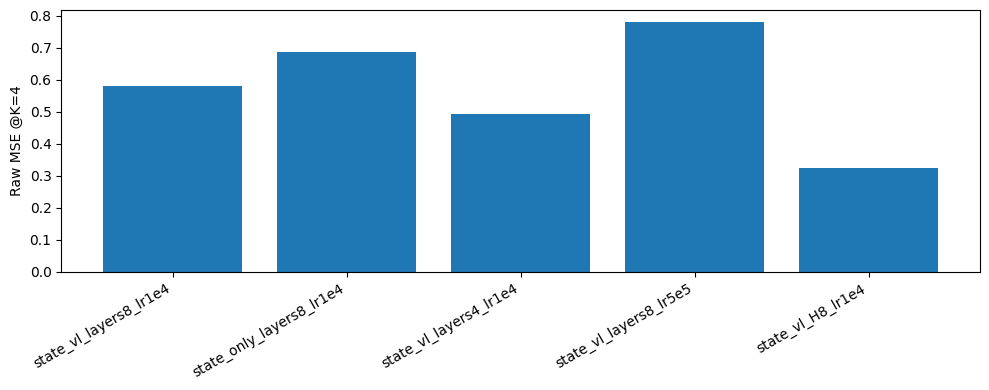

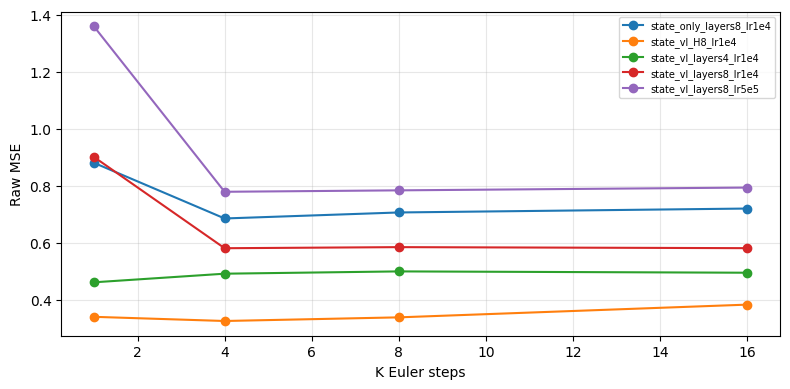

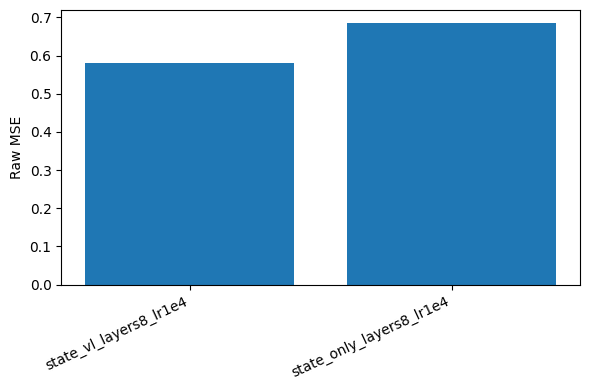

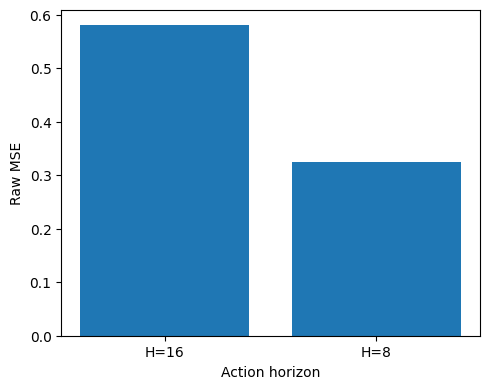

{
  "status": "completed",
  "num_completed": 7,
  "completed_types": [
    "checkpoint_stage",
    "component",
    "horizon",
    "hyperparam",
    "model"
  ],
  "missing_or_skipped_required_types": [],
  "output_root": "/kaggle/working/gr00t_official_ablation"
}
- ablation_bar_chart.png 0.049 MB
- ablation_summary.csv 0.002 MB
- ablation_summary.json 0.011 MB
- component_ablation.png 0.034 MB
- horizon_ablation.csv 0.001 MB
- horizon_ablation.png 0.016 MB
- k_step_tradeoff.csv 0.002 MB
- k_step_tradeoff.png 0.061 MB
- pretrain_posttrain_comparison.csv 0.0 MB


In [7]:
def load_stage_model(ckpt_path):
    ckpt=torch.load(ckpt_path,map_location=device); cfg=ckpt["config"]
    model=OfficialMiniVLDiT(44,44,cfg["state_horizon"],cfg["action_horizon"],cfg["vl_feature_dim"],cfg["hidden_dim"],cfg["num_layers"],cfg["num_heads"],cfg["dropout"]).to(device)
    model.load_state_dict(ckpt["model_state_dict"]); model.eval()
    bad=[k for k,v in ckpt["model_state_dict"].items() if torch.is_tensor(v) and not bool(torch.isfinite(v).all())]
    if bad: raise RuntimeError(f"Non-finite tensors in {ckpt_path.name}: {bad[:5]}")
    return model, ckpt, cfg

def eval_existing_checkpoint_stage(label, ckpt_name):
    H=16; ctx=CONTEXTS.get(H)
    if not ctx or not ctx.get("available") or ctx.get("run_root") is None:
        return {"run":label,"status":"skipped","type":"checkpoint_stage","reason":"missing H16 context or Notebook 03b run root"}
    ckpt_path=ctx["run_root"]/ckpt_name
    if not ckpt_path.exists():
        return {"run":label,"status":"skipped","type":"checkpoint_stage","reason":f"missing {ckpt_name}"}
    try:
        ev=MultiBatchDS(ctx,"test",True,MAX_EVAL_SAMPLES)
        el=make_loader(ev, train=False)
        model, ckpt, cfg=load_stage_model(ckpt_path)
        am=torch.tensor(ev.am,device=device)[None,None,:]; ast=torch.tensor(ev.asd,device=device)[None,None,:]
        @torch.no_grad()
        def sample_stage(state,vl,K=4):
            x=torch.zeros(state.size(0),H,44,device=state.device,dtype=state.dtype); dt=1.0/K
            for k in range(K):
                tt=torch.full((state.size(0),),k/K,device=state.device,dtype=state.dtype)
                x=torch.nan_to_num(x+dt*model(x,state,vl,tt),nan=0.0,posinf=0.0,neginf=0.0)
            return x
        sq=ab=count=samples=0; start=time.time()
        with torch.no_grad():
            for b in tqdm(el,desc=f"eval {label}"):
                state,action,mask,vl=_to_device(b)
                pred=sample_stage(state,vl,4)*mask
                diff=(pred.float()*ast+am)-(action.float()*ast+am)
                sq+=float((diff.square()*mask).sum().cpu()); ab+=float((diff.abs()*mask).sum().cpu()); count+=int(mask.sum().cpu()); samples+=int(action.size(0))
        mse=sq/max(count,1)
        return {"run":label,"status":"completed","type":"checkpoint_stage","use_vl":True,"H":H,"layers":cfg.get("num_layers"),"hidden_dim":cfg.get("hidden_dim"),"lr":cfg.get("learning_rate"),"global_steps":int(ckpt.get("global_step",0)),"raw_mse":mse,"raw_mae":ab/max(count,1),"raw_rmse":math.sqrt(mse),"eval_samples":samples,"K":4,"checkpoint":ckpt_name,"eval_elapsed_sec":round(time.time()-start,2)}
    except Exception as exc:
        return {"run":label,"status":"skipped","type":"checkpoint_stage","reason":repr(exc)}
    finally:
        if torch.cuda.is_available(): torch.cuda.empty_cache()

stage_results=[eval_existing_checkpoint_stage("pretrain_only","pretrain_checkpoint.pt"), eval_existing_checkpoint_stage("posttrain_task_specific","posttrain_checkpoint.pt")]
stage_df=pd.DataFrame(stage_results)
stage_df.to_csv(OUTPUT_ROOT/"pretrain_posttrain_comparison.csv",index=False)

summary_df=pd.DataFrame([{k:v for k,v in r.items() if k!="k_results"} for r in results])
summary_df=pd.concat([summary_df,stage_df],ignore_index=True,sort=False)
summary_df.to_csv(OUTPUT_ROOT/"ablation_summary.csv",index=False)
k_rows=[]
for r in results:
    if r.get("status")=="completed":
        for kr in r["k_results"]: k_rows.append({"run":r["run"],"type":r["type"],"H":r["H"],"use_vl":r["use_vl"],"layers":r["layers"],"lr":r["lr"],**kr})
k_df=pd.DataFrame(k_rows)
k_df.to_csv(OUTPUT_ROOT/"k_step_tradeoff.csv",index=False)

display(summary_df); display(stage_df); display(k_df.head())
completed=summary_df[summary_df.status=="completed"] if "status" in summary_df else pd.DataFrame()
plot_df=completed[completed.type!="checkpoint_stage"] if len(completed) and "type" in completed else completed
if len(plot_df):
    plt.figure(figsize=(10,4)); plt.bar(plot_df.run, plot_df.raw_mse); plt.xticks(rotation=30,ha="right"); plt.ylabel("Raw MSE @K=4"); plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"ablation_bar_chart.png",dpi=160); plt.show()
if len(k_df):
    plt.figure(figsize=(8,4))
    for run, sdf in k_df.groupby("run"):
        plt.plot(sdf.K, sdf.raw_mse, marker="o", label=run)
    plt.xlabel("K Euler steps"); plt.ylabel("Raw MSE"); plt.grid(True,alpha=.3); plt.legend(fontsize=7); plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"k_step_tradeoff.png",dpi=160); plt.show()
component_df=summary_df[(summary_df.status=="completed") & (summary_df.type.astype(str).str.contains("component", na=False))]
if len(component_df):
    plt.figure(figsize=(6,4)); plt.bar(component_df.run, component_df.raw_mse); plt.xticks(rotation=25,ha="right"); plt.ylabel("Raw MSE"); plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"component_ablation.png",dpi=160); plt.show()
# Horizon ablation must compare the H=8 run against the matching H=16 baseline.
# Filtering only type == "horizon" would keep H=8 alone and produce a one-bar chart.
horizon_runs = ["state_vl_layers8_lr1e4", "state_vl_H8_lr1e4"]
horizon_df = summary_df[summary_df.run.isin(horizon_runs)].copy() if "run" in summary_df else pd.DataFrame()
if len(horizon_df):
    horizon_df["horizon_label"] = horizon_df["H"].apply(lambda h: f"H={int(h)}" if pd.notna(h) else "H=?")
    horizon_df["plot_order"] = horizon_df["H"].astype(float)
    horizon_df = horizon_df.sort_values("plot_order", ascending=False).drop(columns=["plot_order"])
    horizon_df.to_csv(OUTPUT_ROOT/"horizon_ablation.csv",index=False)
    completed_horizon_df = horizon_df[horizon_df.status=="completed"] if "status" in horizon_df else horizon_df
    if len(completed_horizon_df):
        plt.figure(figsize=(5,4))
        plt.bar(completed_horizon_df.horizon_label, completed_horizon_df.raw_mse)
        plt.xlabel("Action horizon")
        plt.ylabel("Raw MSE")
        plt.tight_layout()
        plt.savefig(OUTPUT_ROOT/"horizon_ablation.png",dpi=160)
        plt.show()

required_types={"component","model","hyperparam","horizon"}
completed_types=set()
for t in completed.type.dropna().astype(str):
    for part in t.split('/'):
        completed_types.add(part)
summary={"status":"completed","num_runs":len(results),"num_completed":int(len(completed)),"completed_types":sorted(completed_types),"missing_or_skipped_required_types":sorted(required_types-completed_types),"required_ablation_types":["component","model","inference_K","hyperparam","horizon_H8_vs_H16"],"additional_analysis":["pretrain_only_vs_posttrain_task_specific"],"metrics_space":"denormalized_raw_action_space","uses_action_mask":True,"full_train_epoch_per_completed_run":bool(all(r.get("full_train_epoch_completed", True) for r in results if r.get("status")=="completed")),"eval_full_test_split_per_completed_run":bool(all(r.get("full_eval_completed", True) for r in results if r.get("status")=="completed")),"H16_context":{"prepared_roots":[str(r) for r in CONTEXTS[16].get("prepared_roots",[])],"encoded_roots":[str(info["root"]) for info in CONTEXTS[16].get("encoded_infos",[])],"train_encoded":CONTEXTS[16].get("train_encoded"),"test_encoded":CONTEXTS[16].get("test_encoded"),"run_root":str(CONTEXTS[16].get("run_root"))},"H8_context":{"available":CONTEXTS[8].get("available"),"reason":CONTEXTS[8].get("reason"),"source":CONTEXTS[8].get("source"),"derived_from_H":CONTEXTS[8].get("derived_from_H"),"train_encoded":CONTEXTS[8].get("train_encoded"),"test_encoded":CONTEXTS[8].get("test_encoded")},"results":results,"pretrain_posttrain_comparison":stage_results}
(OUTPUT_ROOT/"ablation_summary.json").write_text(json.dumps(summary,indent=2),encoding="utf-8")
print(json.dumps({"status":summary["status"],"num_completed":summary["num_completed"],"completed_types":summary["completed_types"],"missing_or_skipped_required_types":summary["missing_or_skipped_required_types"],"output_root":str(OUTPUT_ROOT)},indent=2))
for p in sorted(OUTPUT_ROOT.iterdir()): print("-", p.name, round(p.stat().st_size/(1024**2),3), "MB")
